# **Multi-layer Perceptron**


In [2]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
from tensorflow import keras
#remove warnings
import warnings
warnings.filterwarnings('ignore')


# Load tips dataset
tips = sns.load_dataset('tips')

# Preprocessing
# Converting categorical variables to dummy variables
tips = pd.get_dummies(tips, drop_first=True)

# Selecting features and target (predicting 'tip' based on other features)
X = tips.drop('tip', axis=1)
y = tips['tip']

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Standardizing the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Building the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', 
                          input_shape=(X_train.shape[1],)), # Input layer
    
    tf.keras.layers.Dense(32, activation='relu'), # Hidden layer
    
    tf.keras.layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Training the model
model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

# Evaluating the model (using Mean Squared Error)
loss = model.evaluate(X_test, y_test, verbose=0)
print('Mean Squared Error: ', loss[0])

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.9894 - mae: 2.6215
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.7176 - mae: 2.1485 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.9063 - mae: 1.7276 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.4553 - mae: 1.3931 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.5044 - mae: 1.1795 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9857 - mae: 1.0574 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6962 - mae: 0.9876 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5084 - mae: 0.9421 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3958 - mae: 0.9123 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3281 - mae: 0.8809  
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2772 - mae: 0.8603 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2491 - mae: 0.8483 
Epoch 13/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

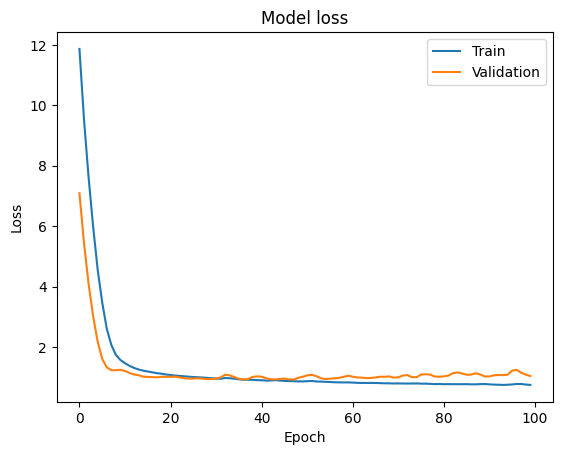

In [3]:
# Building the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Input layer
    tf.keras.layers.Dense(32, activation='relu'), # Hidden layer
    tf.keras.layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# train the model and plot the training and testing loss and accuracy at each epoc
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0, validation_data=(X_test, y_test))

# Evaluating the model (using Mean Squared Error)
loss = model.evaluate(X_test, y_test, verbose=0)
loss

# Plotting the training and testing loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# **Assignment:** what is a Validation Set? or validation loss?

Both the Validation Set and Validation Loss are critical concepts in machine learning, particularly in deep learning, as they help ensure a model generalizes well to new, unseen data and does not simply memorize the training data.

## 1. What is a Validation Set?

A **Validation Set** (also known as a **Development Set** or **Dev Set**) is a distinct subset of the original dataset used to **evaluate a model's performance during the training phase** and **tune the model's hyperparameters**.

### The Three Data Splits

In standard machine learning practice, the complete dataset is typically split into three parts:

| Set Name | Purpose | How it is used |
| :--- | :--- | :--- |
| **1. Training Set** (60-80% of data) | Used to **fit the model's parameters** (weights and biases). This is the data the model *learns* from. | The model sees and adjusts its internal structure based on this data. |
| **2. Validation Set** (10-20% of data) | Used to **tune hyperparameters** and perform **model selection** (e.g., choosing the best learning rate, number of layers, or regularization strength). | The model's performance is checked on this data after each epoch to guide decisions, but the data itself is *not* used in the calculation of the gradient descent update. |
| **3. Test Set** (10-20% of data) | Used to **provide a final, unbiased evaluation** of the chosen, fully-tuned model. | This set is kept completely isolated and is only touched once, at the very end, to report the final, expected performance in the real world. |

### Why is the Validation Set Necessary?

The validation set serves as an intermediate checkpoint:

* **Hyperparameter Tuning:** If you used the Training Set for tuning, you'd be overestimating performance. If you used the Test Set for tuning, you'd contaminate the final evaluation. The Validation Set provides a safe, independent set for comparison.
* **Preventing Overfitting:** It is the primary tool for detecting **overfitting** (when the model performs excellently on the Training Set but poorly on unseen data).
* **Early Stopping:** In deep learning, training often stops when the error on the validation set stops improving or begins to increase, a process called **Early Stopping**.

---

## 2. What is Validation Loss?

**Validation Loss** is the value of the **loss function** (e.g., Mean Squared Error or Cross-Entropy) calculated by the model on the **Validation Set** at specific intervals (usually after every *epoch* or iteration of the training process).

### The Role of Monitoring Both Losses

By plotting and comparing the **Training Loss** and the **Validation Loss** over time (epochs), we can diagnose the training process:

| Scenario | Training Loss | Validation Loss | Diagnosis | Action |
| :--- | :--- | :--- | :--- | :--- |
| **Healthy Training** | Decreases steadily. | Decreases steadily and stays close to Training Loss. | The model is learning and generalizing well. | Continue training. |
| **Overfitting (The Danger)** | Decreases to a very low value. | **Starts increasing** after a certain point. | The model is memorizing the noise in the training data, losing the ability to generalize. | Stop training immediately (**Early Stopping**) or increase regularization. |
| **Underfitting** | Remains high. | Remains high and may mirror Training Loss. | The model is too simple or hasn't been trained enough to capture the underlying patterns. | Increase model complexity (more layers/neurons) or train longer. |

The key concept is that as long as the **Validation Loss** is decreasing, the model is successfully generalizing to new data. Once the Validation Loss begins to rise, you know the model has peaked in its usefulness and is starting to overfit.

---

# Early Stopping of Epochs

In [4]:
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.losses import MeanSquaredError
from keras.metrics import MeanAbsoluteError
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 13.2588 - val_loss: 8.3124
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 10.8522 - val_loss: 6.6650
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 8.9692 - val_loss: 5.2829
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.3713 - val_loss: 4.0733
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5.9217 - val_loss: 3.0486
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4.6026 - val_loss: 2.2686
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.5342 - val_loss: 1.7627
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.7601 - val_loss: 1.4934
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.2114 - val_loss: 1.4049
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.8657 - val_loss: 1.3476
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.6783 - val_loss: 1.3009
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.5123 - val_

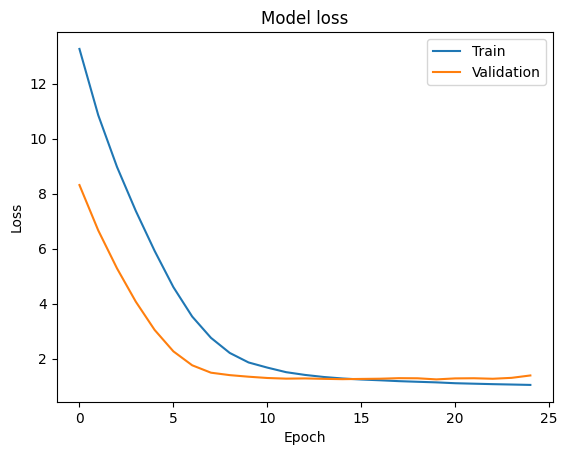

In [5]:
# Building the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Input layer
    tf.keras.layers.Dense(32, activation='relu'), # Hidden layer
    tf.keras.layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Define the callback function
early_stopping = EarlyStopping(patience=5)

# Train the model with the callback function
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])

# Evaluating the model (using Mean Squared Error)
loss = model.evaluate(X_test, y_test, verbose=0)
loss

# Plotting the training and testing loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()